## 6. 決定分析

### 6.1 値段当てゲーム　問題

1. 商品を確認する前に、出場者はショーケースの値段についてどのような事前信念を持つべきだろう。

2. 商品を見た後で、出場者は、その信念をどのように更新すべきだろうか。

3. 事後確率分布に基づいて、出場者はどう回答すべきだろうか。

### 6.2 事前確率



In [2]:
import csv
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from scipy.signal import find_peaks
from collections import Counter


def ReadData(filename='showcases.2011.csv'):
    """Reads a CSV fine of data.
    
    Args:
        filename: string filename
        
    Returns: sequence of (price1 price2 bid1 bid2 diff1 diff2) tuples"""

    fp = open(filename)
    reader = csv.reader(fp)
    res = []

    raw = pd.read_csv(filename, header = None)
    clean = raw.apply(pd.to_numeric, errors="coerce")
    clean = clean.dropna(how="all")

    clean.index = ["Showcase1", "Showcase2",
                   "Bid1", "Bid2",
                   "Diff1", "Diff2"]
    df = clean.T
    df = df[1:]

    print(df)


    for t in reader:
        _heading = t[0]
        data = t[1:]
        try:
            data = [int(x) for x in data]
            # print(heading, data[0], len(data))
            res.append(data)
        except ValueError:
            pass
            

    fp.close()
    return df

price_data = ReadData(filename='showcases.2011.csv')
price_data2 = ReadData(filename='showcases.2012.csv')


price_data3 = pd.concat([price_data, price_data2], axis=0, ignore_index=True)

price_data3

     Showcase1  Showcase2     Bid1     Bid2    Diff1    Diff2
1      50969.0    45429.0  42000.0  34000.0   8969.0  11429.0
2      21901.0    34061.0  14000.0  59900.0   7901.0 -25839.0
3      32815.0    53186.0  32000.0  45000.0    815.0   8186.0
4      44432.0    31428.0  27000.0  38000.0  17432.0  -6572.0
5      24273.0    22320.0  18750.0  23000.0   5523.0   -680.0
..         ...        ...      ...      ...      ...      ...
187    26993.0    33337.0  41000.0  26888.0 -14007.0   6449.0
188    29390.0    26314.0  23052.0  16000.0   6338.0  10314.0
189    34920.0    31278.0  27800.0  30022.0   7120.0   1256.0
190    30323.0    31285.0  27000.0  21000.0   3323.0  10285.0
191    46638.0    42319.0  29900.0  33000.0  16738.0   9319.0

[191 rows x 6 columns]
     Showcase1  Showcase2     Bid1     Bid2    Diff1    Diff2
1      40811.0    62485.0  22000.0  40500.0  18811.0  21985.0
2      31259.0    32972.0  10000.0  21000.0  21259.0  11972.0
3      41943.0    24755.0  39500.0  22500.0   

,Showcase1,Showcase2,Bid1,Bid2,Diff1,Diff2
0,50969.0,45429.0,42000.0,34000.0,8969.0,11429.0
1,21901.0,34061.0,14000.0,59900.0,7901.0,-25839.0
2,32815.0,53186.0,32000.0,45000.0,815.0,8186.0
3,44432.0,31428.0,27000.0,38000.0,17432.0,-6572.0
4,24273.0,22320.0,18750.0,23000.0,5523.0,-680.0
...,...,...,...,...,...,...
308,25375.0,31986.0,36000.0,32000.0,-10625.0,-14.0
309,24949.0,30696.0,20500.0,31000.0,4449.0,-304.0
310,23662.0,22329.0,26000.0,20000.0,-2338.0,2329.0
311,23704.0,34325.0,23800.0,34029.0,-96.0,296.0


In [3]:
#price_data.append(price_data2)

Showcase1 = price_data3["Showcase1"].to_numpy()  # 1番目の数字
Showcase2 = price_data3["Showcase2"].to_numpy() # 2番目の数字

print(len(Showcase1))
rounded = [round(x,-3) for x in Showcase1]
counter = Counter(rounded)

print(counter.most_common())

313
[(29000.0, 26), (24000.0, 21), (27000.0, 20), (28000.0, 18), (30000.0, 18), (22000.0, 17), (25000.0, 17), (23000.0, 16), (31000.0, 15), (26000.0, 15), (21000.0, 13), (33000.0, 12), (32000.0, 12), (35000.0, 11), (37000.0, 10), (36000.0, 10), (34000.0, 9), (40000.0, 8), (39000.0, 8), (38000.0, 6), (20000.0, 6), (41000.0, 4), (44000.0, 3), (47000.0, 3), (42000.0, 3), (51000.0, 2), (45000.0, 2), (50000.0, 2), (52000.0, 1), (55000.0, 1), (58000.0, 1), (48000.0, 1), (53000.0, 1), (46000.0, 1)]


<function matplotlib.pyplot.tight_layout(*, pad: 'float' = 1.08, h_pad: 'float | None' = None, w_pad: 'float | None' = None, rect: 'tuple[float, float, float, float] | None' = None) -> 'None'>

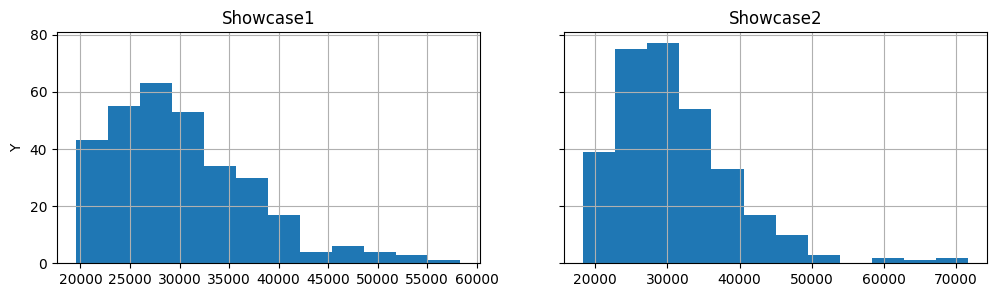

In [4]:
y_data = [
    Showcase1,
    Showcase2
]

titles = ["Showcase1", "Showcase2"]

fig, axes = plt.subplots(
    nrows=1,
    ncols = len(y_data),
    figsize = (12,3),
    sharey=True
)

for ax, y, title in zip(axes, y_data, titles):

    ax.hist(y, bins=12)
    ax.set_title(title)
    ax.grid(True)

axes[0].set_ylabel("Y")
plt.tight_layout

事前分布

$ P(H) $

ショーケース１の価格はどの辺に現れやすいか。

27847, 27560


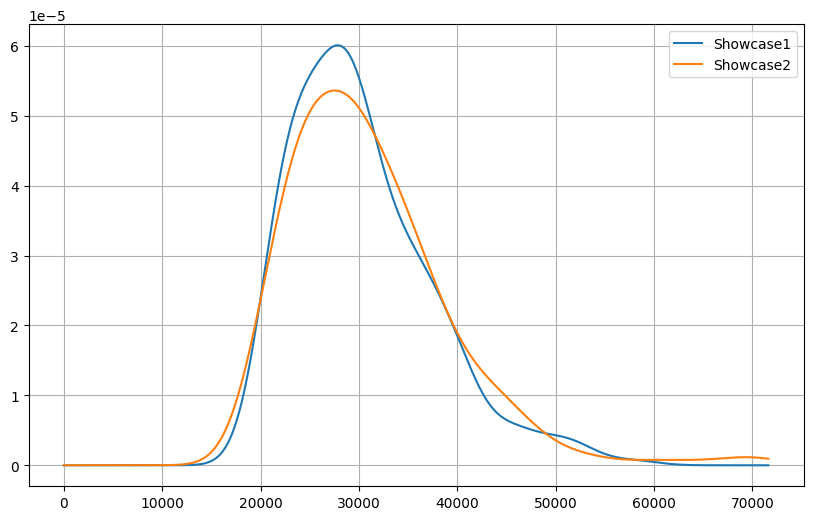

In [5]:
kde1 = gaussian_kde(Showcase1)
kde2 = gaussian_kde(Showcase2)

xmin = min(min(Showcase1), min(Showcase2))
xmax = max(max(Showcase1), max(Showcase2))

x = np.linspace(0,xmax,500)

pdf1 = kde1(x)
pdf2 = kde2(x)

mode_price = x[np.argmax(pdf1)]
mode_price2 = x[np.argmax(pdf2)]
print(f'{mode_price:.0f}, {mode_price2:.0f}')


plt.figure(figsize=(10,6))
plt.plot(x, pdf1, label="Showcase1")
plt.plot(x, pdf2, label='Showcase2')
plt.grid(True)
plt.legend()


In [6]:
price_data3['e'] = price_data3['Showcase1'] - price_data3['Bid1'] - price_data3['Diff1']
price_data3['e'].sum()

0.0

### 6.3 確率密度関数

KDEは各データ点の上に小さなベルカーブ（正規分布）を乗せる

そして、全部足し合わせる


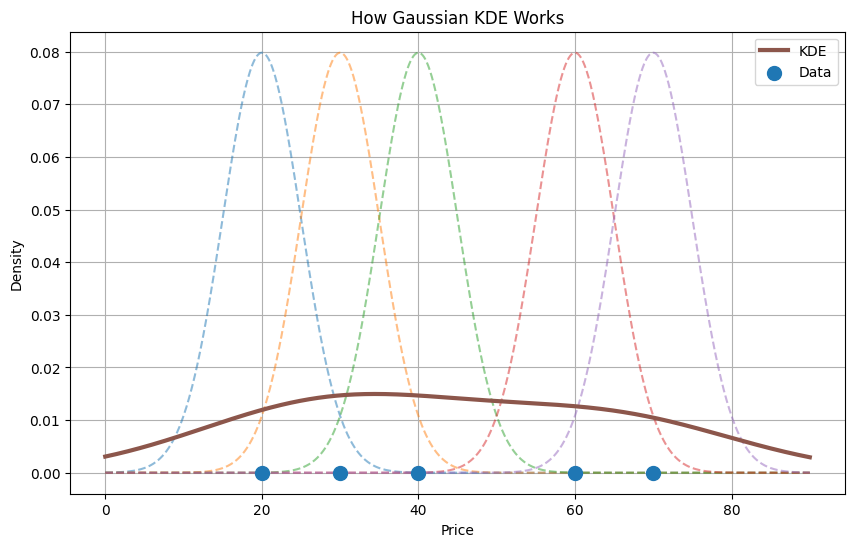

In [7]:
from scipy.stats import norm

data = np.array([20,30,40,60,70])

x = np.linspace(0,90,1000)

# バンド幅
bw = 5

plt.figure(figsize=(10,6))

# 各データ点のガウスカーネル
for d in data:
    y = norm.pdf(x, loc=d, scale=bw)
    plt.plot(x,y,'--',alpha=0.5)

# KDE
kde = gaussian_kde(data)

plt.plot(x, kde(x), linewidth=3, label='KDE')

# 元データの位置
plt.scatter(data, np.zeros_like(data), s=100, zorder=5, label='Data')

plt.xlabel("Price")
plt.ylabel("Density")
plt.title("How Gaussian KDE Works")
plt.legend()
plt.grid(True)

### 6.5 出場者をモデル化する

誤差分布

$ P(error) $ 

<function matplotlib.pyplot.tight_layout(*, pad: 'float' = 1.08, h_pad: 'float | None' = None, w_pad: 'float | None' = None, rect: 'tuple[float, float, float, float] | None' = None) -> 'None'>

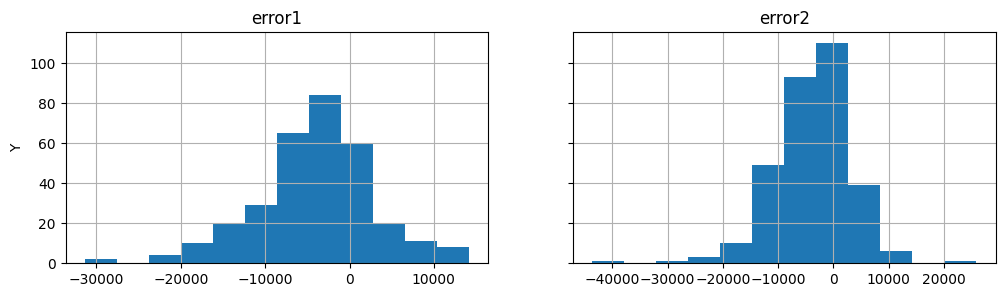

In [8]:
# errorを作る

error1 = price_data3["Bid1"] - price_data3["Showcase1"]
error2 = price_data3["Bid2"] - price_data3["Showcase2"]

x_min = min(min(error1), min(error2))
x_max = max(max(error1), max(error2))

# ヒストグラムを見る

y_data = [
    error1,
    error2
]

titles = ["error1", "error2"]

fig, axes = plt.subplots(
    nrows=1,
    ncols = len(y_data),
    figsize = (12,3),
    sharey=True
)



for ax, y, title in zip(axes, y_data, titles):

    ax.hist(y, bins=12)
    ax.set_title(title)
    ax.grid(True)

axes[0].set_ylabel("Y")
plt.tight_layout




error1 mean: -4116
error1 std: 6900
error2 mean: -3676
error2 std: 6886


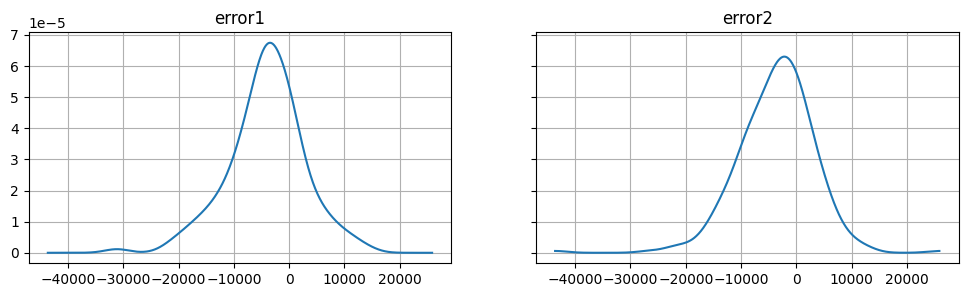

In [9]:
fig, axes = plt.subplots(
    nrows=1,
    ncols = len(y_data),
    figsize = (12,3),
    sharey=True
)


titles = ["error1", "error2"]
x = np.linspace(x_min,x_max,1000)

for ax, y, title in zip(axes, y_data, titles):

    kde = gaussian_kde(y)
    ax.plot(x,kde(x))
    ax.set_title(title)
    ax.grid(True)

    print(f'{title} mean: {y.mean():.0f}')
    print(f'{title} std: {y.std():.0f}')

    

In [10]:
error2.mean()

-3675.891373801917

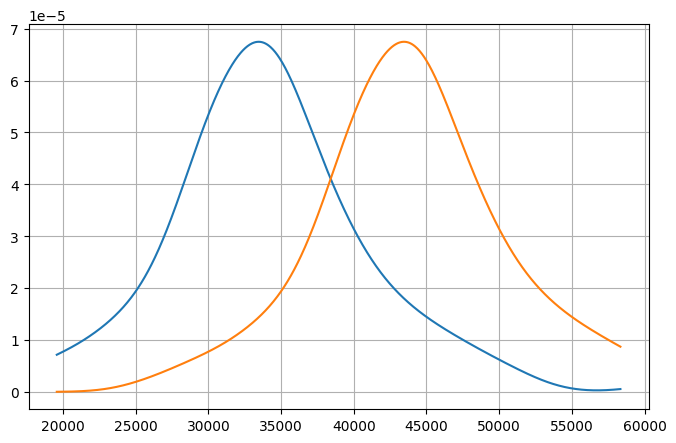

In [14]:
# 予測額 (guess) を決める

guesses = [30000,40000]
plt.figure(figsize=(8,5))
# 価格候補を並べる
for guess in guesses:

    kde_error = gaussian_kde(error1)

    prices1 = price_data3['Showcase1']

    prices = np.linspace(prices1.min(), prices1.max(),1000)

    errors = guess - prices
    likelihood = kde_error(errors)

    plt.plot(prices, likelihood)

plt.grid(True)



$ P(D|H) $

In [31]:
guess = 30000

xs = np.linspace(0,75000,1000)

error = guess - xs

likelihood = kde_error(guess - xs)

likelihood_scaled = likelihood / likelihood.sum()



In [32]:
prior = kde1(xs)
prior = prior / prior.sum()

posterior = prior * likelihood
posterior /= posterior.sum()

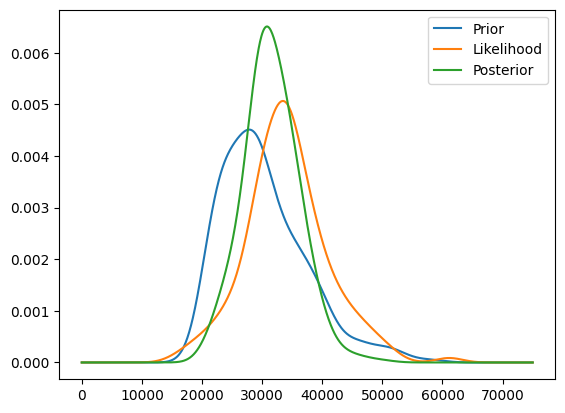

In [33]:
plt.plot(xs, prior, label="Prior")
plt.plot(xs, likelihood_scaled, label="Likelihood")
plt.plot(xs, posterior, label="Posterior")
plt.legend()

In [29]:
print(prior.max())
print(likelihood.max())
print(posterior.max())

0.004812199001770235
6.747807144131805e-05
0.006942887662406436


In [34]:
prior = kde_price(xs)

likelihood = kde_error(guess - xs)

unnormalized = prior * likelihood

posterior = unnormalized / unnormalized.sum()

print("prior max       :", prior.max())
print("likelihood max  :", likelihood.max())
print("unnormalized max:", unnormalized.max())
print("posterior max   :", posterior.max())
print("posterior sum   :", posterior.sum())

prior max       : 6.009285383336608e-05
likelihood max  : 6.747731178578113e-05
unnormalized max: 3.0327126363411594e-09
posterior max   : 0.006508934876287826
posterior sum   : 1.0


prior sum      = 0.9999999999999998
likelihood sum = 1.0
posterior sum  = 1.0000000000000002


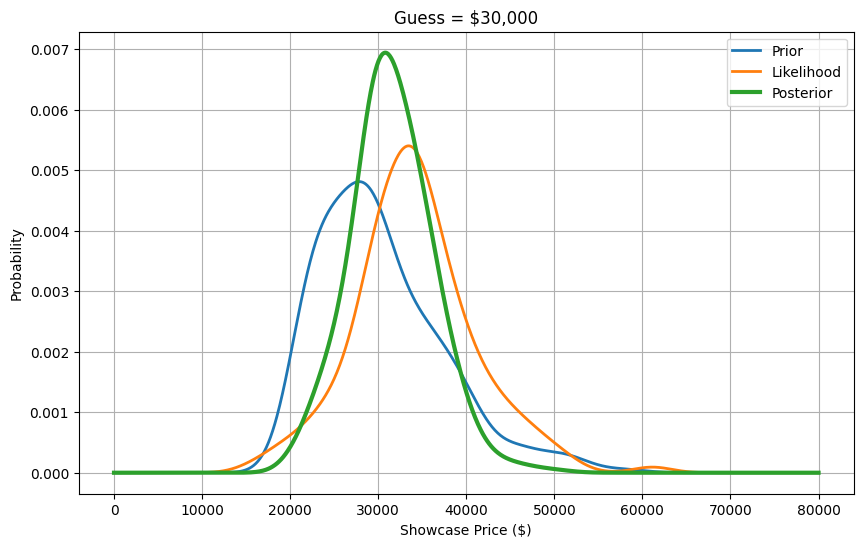

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# -----------------------------------
# 1. データ
# -----------------------------------

showcase = price_data3["Showcase1"].dropna().values
bid       = price_data3["Bid1"].dropna().values

error = bid - showcase

# -----------------------------------
# 2. KDE
# -----------------------------------

kde_price = gaussian_kde(showcase)
kde_error = gaussian_kde(error)

# -----------------------------------
# 3. 観測データ
# -----------------------------------

guess = 30000

# 仮説空間
xs = np.linspace(0, 80000, 1000)

# -----------------------------------
# 4. Prior
# -----------------------------------

prior = kde_price(xs)

# 離散確率化
prior = prior / prior.sum()

# -----------------------------------
# 5. Likelihood
# -----------------------------------

errors = guess - xs

likelihood = kde_error(errors)

# 比較しやすいように正規化
likelihood = likelihood / likelihood.sum()

# -----------------------------------
# 6. Posterior
# -----------------------------------

posterior = prior * likelihood

posterior = posterior / posterior.sum()

# -----------------------------------
# 7. 確認
# -----------------------------------

print("prior sum      =", prior.sum())
print("likelihood sum =", likelihood.sum())
print("posterior sum  =", posterior.sum())

# -----------------------------------
# 8. グラフ
# -----------------------------------

plt.figure(figsize=(10,6))

plt.plot(xs, prior,
         label="Prior",
         linewidth=2)

plt.plot(xs, likelihood,
         label="Likelihood",
         linewidth=2)

plt.plot(xs, posterior,
         label="Posterior",
         linewidth=3)

plt.xlabel("Showcase Price ($)")
plt.ylabel("Probability")

plt.title(f"Guess = ${guess:,.0f}")

plt.legend()
plt.grid()

plt.show()